In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/participants.csv")
df.head()

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


# Count for Duplicate Rows:

I checked for duplicate rows and found the most frequent value in each column to find inconsistencies or dominanting categories.

In [3]:
print(f"Duplicated Rows: {df.duplicated().sum()}")
print("Seeing Inconsistent Values:")
print(df.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))

Duplicated Rows: 0
Seeing Inconsistent Values:
               most_frequent_value
user_code               007b8190cf
gender                           f
age_range                    35-44
city                        Moscow
country                     Russia
height                       168.0
weight                        60.0
symptoms_onset            5/6/2020


# Central Tendency & Dispersion Measures:

I calculated central tendency measures (mean, median) and dispersion measures (std, min, max) for quantitative columns to assess the distribution of numeric features. Finding these values helps quickly identify features' scale, features' variability, and potential outliers before analzying the data more deeply.

In [4]:
quant_cols = df.select_dtypes(include=[np.number]).columns

print("Measures of Central Tendency:")
print(df[quant_cols].describe().loc[['mean', '50%']])
print("\nMeasures of Dispersion:")
print(df[quant_cols].describe().loc[['std', 'min', 'max']])

Measures of Central Tendency:
          height     weight
mean  169.976393  77.927757
50%   168.000000  74.344000

Measures of Dispersion:
         height      weight
std   12.400103   19.552541
min  132.080000   43.500000
max  250.000000  154.221000


# Data Structure & Quality:

I examined the dataset’s dimensions, column types, and missing values to understand its structure and quality. This helps identify potential data cleaning needs and ensures I know what variables are available before deeper analysis.

In [5]:
# Data Structure
print(f"Dimensions: {df.shape}")
print(f"Data Types:\n{df.dtypes}")
print(f"Missing Values:\n{df.isnull().sum()}")

Dimensions: (185, 8)
Data Types:
user_code          object
gender             object
age_range          object
city               object
country            object
height            float64
weight            float64
symptoms_onset     object
dtype: object
Missing Values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64


# Converting Symtoms Onset Variable to Date-Time Object:

I converted the Symptoms Onset variable to a datetime object in order that dates can be correctly sorted, compared, as well as utilized for time-based analysis.

In [6]:
df['symptoms_onset'] = pd.to_datetime(df['symptoms_onset'], errors='coerce')
df.head()

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaT
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,2020-05-15
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,2020-04-05
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,2020-05-06
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,2020-05-27


In [7]:
df.dtypes

user_code                 object
gender                    object
age_range                 object
city                      object
country                   object
height                   float64
weight                   float64
symptoms_onset    datetime64[ns]
dtype: object

# Imputing Missing Values:
Missing values must be imputed because if not, then wrong conclusions can be made about the data.

In [8]:
# Fill missing dates with the median onset date, which is the middle date when all dates are sorted from oldest to newest
median_date = df['symptoms_onset'].median()
df['symptoms_onset'] = df['symptoms_onset'].fillna(median_date)

# Fill missing city values with the mode
mode_city = df['city'].mode()[0]
df['city'] = df['city'].fillna(mode_city)

df.head(15)

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,2020-04-10
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,2020-05-15
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,2020-04-05
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,2020-05-06
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,2020-05-27
5,02a2b827c9,m,25-34,Moscow,Russia,177.00,87.100,2020-03-27
6,02b528c2fe,f,35-44,Moscow,Russia,178.00,64.000,2020-04-10
7,03c83694ae,f,35-44,Burlington,United States,160.02,61.235,2020-04-10
8,05bcfae0a4,m,35-44,Atlanta,United States,NaN,75.977,2020-03-25
9,0bdfbddb2b,f,18-24,Teren'ga,Russia,159.00,73.500,2020-04-01


# Correlation Matrix:

A correlation matrix is helpful in order to evaluate linear relationships among numerical variables in the same dataset. This helps identify strong variable associations, multicollinearity, and feature selection.

Correlation Matrix:
          height    weight
height  1.000000  0.227413
weight  0.227413  1.000000


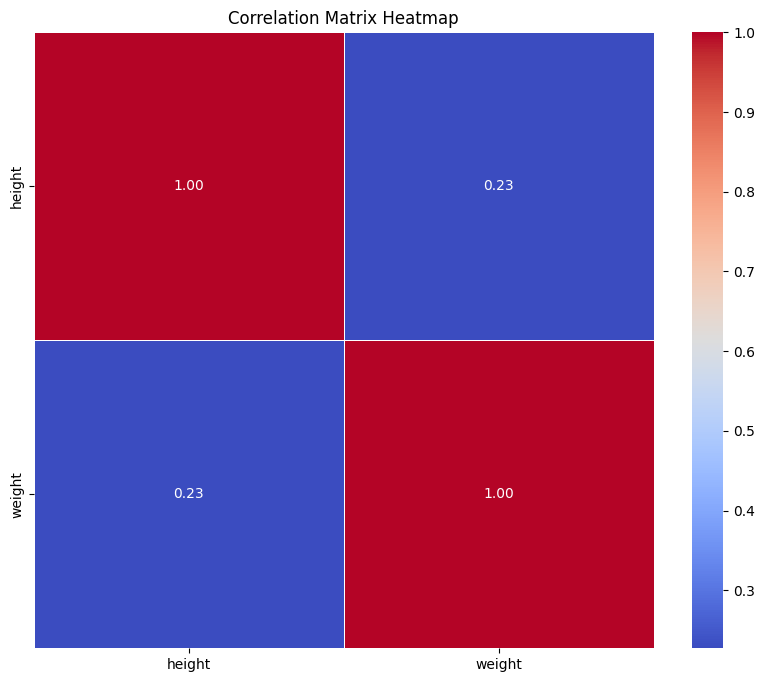

In [9]:
print("Correlation Matrix:")
correlation_matrix = df[quant_cols].corr()
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

# Historgrams of 2 Variables:

I plotted histograms of height and weight to see their distributions to see the shape, spread, and presence of outliers.

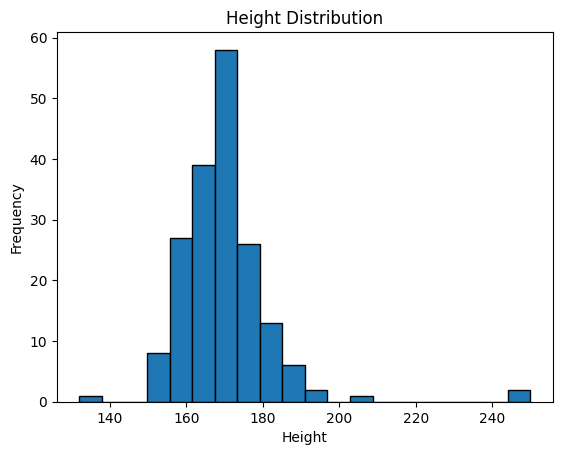

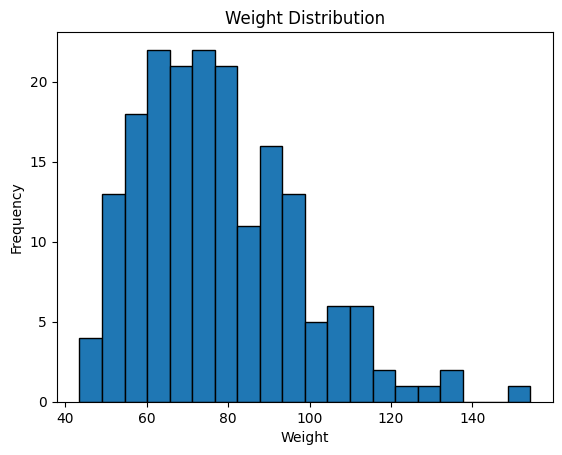

In [10]:
# height histogram
plt.hist(df['height'], bins=20, edgecolor='black')
plt.title('Height Distribution')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.show()

# weight histogram
plt.hist(df['weight'], bins=20, edgecolor='black')
plt.title('Weight Distribution')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()